In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:

import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

In [6]:
df = pd.read_csv('PJME_hourly.csv', parse_dates=[0], index_col=[0])
df

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


In [7]:
df.shape

(145366, 1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


In [9]:
df.columns

Index(['PJME_MW'], dtype='object')

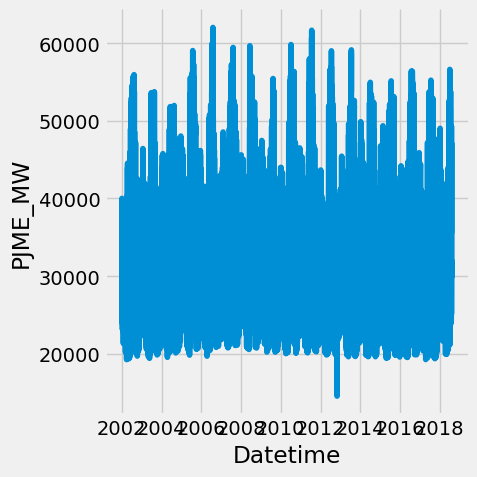

In [10]:
sns.relplot(x='Datetime', y='PJME_MW', kind='line', data=df)

## Train Test Split

In [11]:
# Define the split ratio
split_ratio = 0.8

# Calculate the split index
split_index = int(len(df) * split_ratio)

# Split the data
train = df.iloc[:split_index]
test = df.iloc[split_index:]

In [12]:
train.shape, test.shape

((116292, 1), (29074, 1))

In [13]:
train

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2015-09-24 08:00:00,27884.0
2015-09-24 09:00:00,28777.0
2015-09-24 10:00:00,29610.0


In [14]:
test

,PJME_MW
Datetime,
2015-09-24 13:00:00,32002.0
2015-09-24 14:00:00,32634.0
2015-09-24 15:00:00,33251.0
2015-09-24 16:00:00,33741.0
2015-09-24 17:00:00,34230.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


## features Engineering

In [15]:
# check the index of the data
train.index

DatetimeIndex(['2002-12-31 01:00:00', '2002-12-31 02:00:00',
               '2002-12-31 03:00:00', '2002-12-31 04:00:00',
               '2002-12-31 05:00:00', '2002-12-31 06:00:00',
               '2002-12-31 07:00:00', '2002-12-31 08:00:00',
               '2002-12-31 09:00:00', '2002-12-31 10:00:00',
               ...
               '2015-09-24 03:00:00', '2015-09-24 04:00:00',
               '2015-09-24 05:00:00', '2015-09-24 06:00:00',
               '2015-09-24 07:00:00', '2015-09-24 08:00:00',
               '2015-09-24 09:00:00', '2015-09-24 10:00:00',
               '2015-09-24 11:00:00', '2015-09-24 12:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=116292, freq=None)

In [16]:
# extract the year, month, day, and day of week features

def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

In [17]:
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,4,12,2002,365,31,1
2002-12-31 02:00:00,25147.0,2,1,4,12,2002,365,31,1
2002-12-31 03:00:00,24574.0,3,1,4,12,2002,365,31,1
2002-12-31 04:00:00,24393.0,4,1,4,12,2002,365,31,1
2002-12-31 05:00:00,24860.0,5,1,4,12,2002,365,31,1
...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,1,1,2018,1,1,1
2018-01-01 21:00:00,43751.0,21,0,1,1,2018,1,1,1
2018-01-01 22:00:00,42402.0,22,0,1,1,2018,1,1,1


In [18]:
df.columns.tolist()

['PJME_MW',
 'hour',
 'dayofweek',
 'quarter',
 'month',
 'year',
 'dayofyear',
 'dayofmonth',
 'weekofyear']

## visualization of features and target

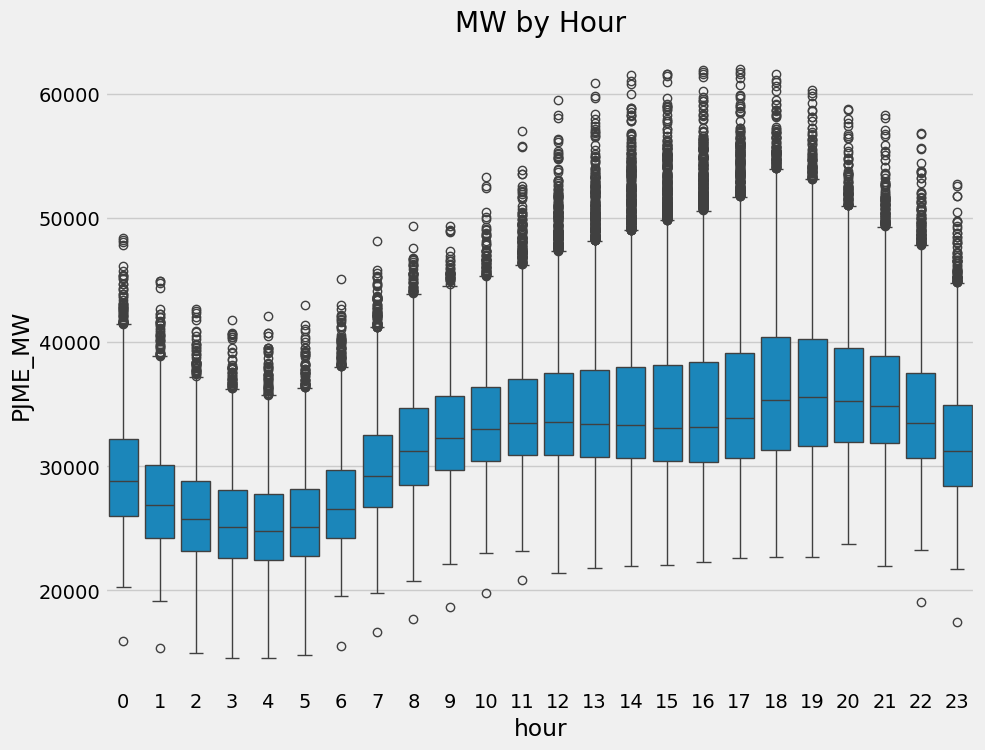

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='hour', y='PJME_MW')
ax.set_title('MW by Hour')
plt.show()

/var/folders/v9/v9j8bf6j2r5cr97thvfgxxyh0000gn/T/ipykernel_60506/2202713226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='PJME_MW', palette='Blues')


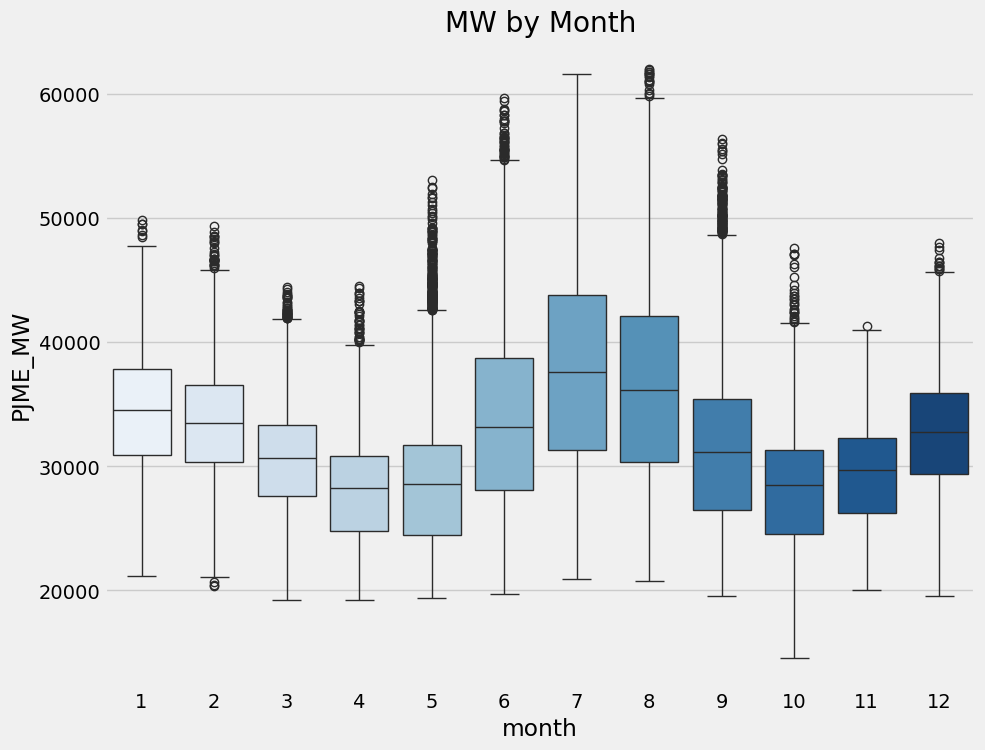

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='month', y='PJME_MW', palette='Blues')
ax.set_title('MW by Month')
plt.show()

# Model Selection

In [73]:
df.columns.to_list()

['PJME_MW',
 'hour',
 'dayofweek',
 'quarter',
 'month',
 'year',
 'dayofyear',
 'dayofmonth',
 'weekofyear']

In [81]:
# apply the create_features function to the train and test data
train = create_features(train)
test = create_features(test)

In [75]:
# define the features and target
FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
TARGET = 'PJME_MW'

In [76]:
# split the data into X_train, y_train, X_test, and y_test
X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]


In [77]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((116292, 6), (116292,), (29074, 6), (29074,))

In [ ]:
# Convert to DMatrix
# dtrain = xgb.DMatrix(data=X_train, label=y_train)
# dtest = xgb.DMatrix(data=X_test, label=y_test)

In [93]:
xgb.XGBRegressor().get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [80]:
from xgboost import XGBRegressor

# Set parameters
xgb_params = {
    'eta': 0.001,
    'max_depth': 10,
    'min_child_weight': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'nthread': 8,
    'seed': 42,
    'verbosity': 1,
}



In [82]:
# Watchlist for evaluation
watchlist = [(dtrain, 'train'), (dtest, 'eval')]

In [85]:
# Train model
model = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=100,
    evals=watchlist,
    early_stopping_rounds=5,
    

)


[0]	train-rmse:6439.96524	eval-rmse:6551.73728
[1]	train-rmse:6435.48772	eval-rmse:6547.41772
[2]	train-rmse:6430.74689	eval-rmse:6542.86717
[3]	train-rmse:6426.05869	eval-rmse:6539.07982
[4]	train-rmse:6421.38678	eval-rmse:6535.31701
[5]	train-rmse:6419.09269	eval-rmse:6533.58858
[6]	train-rmse:6414.41610	eval-rmse:6529.78278
[7]	train-rmse:6410.46802	eval-rmse:6527.14197
[8]	train-rmse:6406.52446	eval-rmse:6524.46711
[9]	train-rmse:6401.62143	eval-rmse:6519.82493
[10]	train-rmse:6396.80235	eval-rmse:6515.74201
[11]	train-rmse:6392.40993	eval-rmse:6512.07556
[12]	train-rmse:6388.01645	eval-rmse:6508.45254
[13]	train-rmse:6385.37510	eval-rmse:6506.63600
[14]	train-rmse:6382.91846	eval-rmse:6505.14438
[15]	train-rmse:6377.90721	eval-rmse:6501.03365
[16]	train-rmse:6375.22217	eval-rmse:6499.13400
[17]	train-rmse:6372.56076	eval-rmse:6497.31217
[18]	train-rmse:6367.76664	eval-rmse:6493.28427
[19]	train-rmse:6363.35672	eval-rmse:6489.03324
[20]	train-rmse:6358.49767	eval-rmse:6484.44083
[2

In [89]:
prediction = model.predict(dtest)
print(prediction)

[32202.998 32226.998 32230.31  ... 32484.521 32335.742 32073.105]


In [90]:
# 
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, prediction))
print(f'RMSE: {rmse}')

RMSE: 6220.644514985173


____

# Feature Importance

In [69]:
xgb_model.get_score(importance_type='weight')

{'dayofyear': 26853.0,
 'hour': 10499.0,
 'dayofweek': 8401.0,
 'quarter': 435.0,
 'month': 2503.0,
 'year': 17670.0}

In [71]:
importance = xgb_model.get_score(importance_type='weight')
for feature, score in importance.items():
    print(f"Feature: {feature}, Importance: {score}")

Feature: dayofyear, Importance: 26853.0
Feature: hour, Importance: 10499.0
Feature: dayofweek, Importance: 8401.0
Feature: quarter, Importance: 435.0
Feature: month, Importance: 2503.0
Feature: year, Importance: 17670.0


Feature: dayofyear, Importance: 26853.0
Feature: hour, Importance: 10499.0
Feature: dayofweek, Importance: 8401.0
Feature: quarter, Importance: 435.0
Feature: month, Importance: 2503.0
Feature: year, Importance: 17670.0


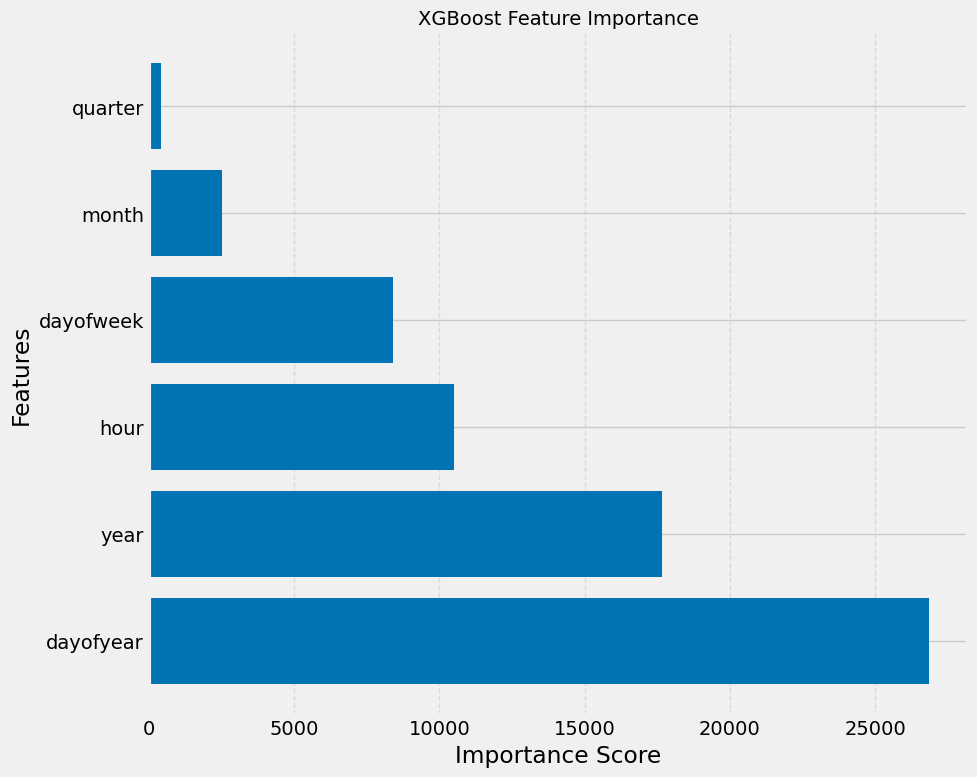

In [72]:
importance = xgb_model.get_score(importance_type='weight')
for feature, score in importance.items():
    print(f"Feature: {feature}, Importance: {score}")

# Plot feature importance as a bar chart
import matplotlib.pyplot as plt
import pandas as pd

# Convert to DataFrame and sort for better visualization
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values('Importance', ascending=False)

# Create the bar chart
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#0173b2')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('XGBoost Feature Importance', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()